In [17]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt 

# Load the CSV file into a DataFrame
df = pd.read_csv('Student_Performance.csv')
print(df.columns)
df

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23
9996,7,64,Yes,8,5,58
9997,6,83,Yes,8,5,74
9998,9,97,Yes,7,0,95


In [18]:
less_than_6 = df[df['Sleep Hours'] < 6]
less_than_6

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
1,4,82,No,4,2,65
3,5,52,Yes,5,2,36
6,7,73,Yes,5,6,63
7,8,45,Yes,4,6,42
9,4,89,No,4,0,69
...,...,...,...,...,...,...
9983,8,87,Yes,4,9,79
9985,8,99,No,5,5,92
9987,9,74,No,4,6,69
9989,3,46,No,5,8,27


In [19]:
print(len(less_than_6)/len(df))

0.3225


In [33]:
sc = df['Previous Scores']
hstud = df['Hours Studied']
sleep = df['Sleep Hours']
paper = df['Sample Question Papers Practiced']

ind = df['Performance Index']

In [32]:
jointDF = pd.concat([sc, ind], axis = 1,join='inner')
corrmat = jointDF.corr()

<Axes: >

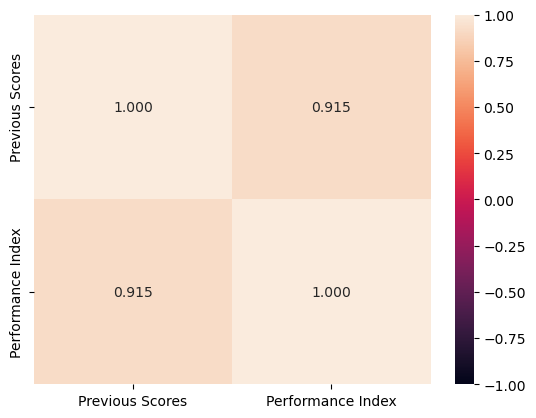

In [26]:
sb.heatmap(corrmat, vmin = -1, vmax = 1, annot = True, fmt=".3f")


In [28]:
# Calculate Q1 (25th percentile)
Q1 = ind.quantile(0.25)

# Calculate Q3 (75th percentile)
Q3 = ind.quantile(0.75)

# Calculate the IQR
IQR = Q3 - Q1
print(IQR)

31.0


In [ ]:
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()

In [29]:
# Returns the column name with the smallest variance
min_var_col = df.var(numeric_only=True).idxmin()
print(min_var_col)

# To see the variance value itself
print(df.var(numeric_only=True).min())



Sleep Hours
2.875951235123142


In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Create a sample dataset (replace with your actual data)
# We use a dictionary to represent 4 predictor columns (X1 to X4) and 1 target (Target)

# Define your features (X) and target (y)
# Select the 4 predictor columns:
X = df[['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']] 
# Select the single target column:
y = df['Performance Index'] 

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% for testing
    random_state=42      # Ensures reproducibility of the split
)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# 3. Initialize the Linear Regression model
model = LinearRegression()

# 4. Fit the model to the training data
model.fit(X_train, y_train)

# 5. Optional: View the model coefficients and intercept
print("\nModel Coefficients (for X1, X2, X3, X4):", model.coef_)
print("Model Intercept:", model.intercept_)

# 6. Optional: Evaluate the model
score = model.score(X_test, y_test)
print(f"\nR^2 Score on Test Data: {score:.3f}")


Training set size: 8000 samples
Testing set size: 2000 samples

Model Coefficients (for X1, X2, X3, X4): [2.85289351 1.01703572 0.47331832 0.19172629]
Model Intercept: -33.602067327491305

R^2 Score on Test Data: 0.989


In [39]:
from sklearn.metrics import r2_score
model = LinearRegression()

# 4. Fit the model on the entire dataset
# The .fit() method learns the coefficients and intercept
model.fit(X, y)

# 5. Make predictions on the same dataset
# We predict the target values for all data points
predictions = model.predict(X)

# 6. Calculate the R^2 score
# We compare the actual target values (y) to the predicted values
r2 = r2_score(y, predictions)

# 7. Report the results
print(f"Model Intercept: {model.intercept_}")
print(f"Model Coefficients: {model.coef_}")
print(f"R^2 Score on the entire dataset: {r2}")

Model Intercept: -33.76372609079438
Model Coefficients: [2.85342921 1.01858354 0.47633298 0.1951983 ]
R^2 Score on the entire dataset: 0.9884981216772581


In [40]:
std_devs = df.std(numeric_only=True)

# 3. Get the column name with the 2nd highest std dev
# nlargest(2) gets top 2, .index[1] gets the second one
second_highest_col = std_devs.nlargest(2).index[1]

print("Column with second highest standard deviation:", second_highest_col)
print("Standard Deviation:", std_devs[second_highest_col])

Column with second highest standard deviation: Previous Scores
Standard Deviation: 17.343152251047066


In [60]:
average_yes = df[df['Extracurricular Activities'] == 'yes']['Performance Index'].mean()


0       91
1       65
2       45
3       36
4       66
        ..
9995    23
9996    58
9997    74
9998    95
9999    64
Name: Performance Index, Length: 10000, dtype: int64

In [50]:
yesavg = yes['Performance Index'].mean()
noavg = no['Performance Index'].mean()
print(yesavg)

nan


In [48]:
print(yesavg - noavg)

nan


In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# 1. Group by 'Extracurricular Activities' and calculate the mean of 'Performance Index'
avg_performance = df.groupby('Extracurricular Activities')['Performance Index'].mean()

print(avg_performance)
# Output will look something like:
# Extracurricular Activities
# No     53.123
# Yes    56.789
# Name: Performance Index, dtype: float64


Extracurricular Activities
No     54.758511
Yes    55.700889
Name: Performance Index, dtype: float64


In [62]:
55.700889-54.758511

0.9423779999999979